In [271]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns

In [272]:
df_cust=pd.read_csv('olist_customers_dataset.csv')
df_loc=pd.read_csv('olist_geolocation_dataset.csv')
df_item=pd.read_csv('olist_order_items_dataset.csv')
df_pay=pd.read_csv('olist_order_payments_dataset.csv')
df_rev=pd.read_csv('olist_order_reviews_dataset.csv')
df_ord=pd.read_csv('olist_orders_dataset.csv')
df_pro=pd.read_csv('olist_products_dataset.csv')
df_sell=pd.read_csv('olist_sellers_dataset.csv')
df_cate=pd.read_csv('product_category_name_translation.csv')

In [273]:
dfs=[df_cust, df_loc, df_item, df_pay, df_rev, df_ord, df_pro, df_sell, df_cate]

In [274]:
for df in dfs :
    print('Info :')
    print(df.info())
    print('*'*50)
    print('Describtion :')
    print(df.describe())
    print('*'*50)
    print('Nulls :')
    print(df.isna().sum())
    print('*'*50)
    print(f'Duplicates :{df.duplicated().sum()}')
    print('*'*50)

Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
**************************************************
Describtion :
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000
**************************************************
Nulls :
customer_id                 0
customer_u

### Nulls : olist_order_reviews, olist_orders, olist_products 

In [275]:
df_rev

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [276]:
df_rev.drop(['review_comment_title', 'review_comment_message'], axis=1, inplace=True)

In [277]:
df_rev.isna().sum()

review_id                  0
order_id                   0
review_score               0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [278]:
df_pro

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [279]:
df_pro.dropna(inplace=True)

In [280]:
df_pro.isna().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [281]:
task1_df = df_ord.merge(df_item, on='order_id', how='inner') \
                  .merge(df_pro, on='product_id', how='inner') \
                  .merge(df_pay, on='order_id', how='inner')

In [282]:
task2_df = df_ord.merge(df_cust, on='customer_id', how='inner')


In [283]:
task3_df = df_sell.merge(df_item, on='seller_id', how='inner') \
                   .merge(df_ord, on='order_id', how='inner') \
                   .merge(df_rev, on='order_id', how='left')

In [284]:
task4_df = df_rev.merge(df_item, on='order_id', how='inner') \
                  .merge(df_pro, on='product_id', how='inner') \
                  .merge(df_ord, on='order_id', how='inner')

In [285]:
task1_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,1,credit_card,3,179.12


In [286]:
task2_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [287]:
task3_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value,...,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_creation_date,review_answer_timestamp
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,4a90af3e85dd563884e2afeab1091394,1,ffb64e34a37740dafb6c88f1abd1fa61,2017-08-25 20:50:19,106.20,9.56,...,delivered,2017-08-21 20:35:44,2017-08-21 20:50:19,2017-08-29 20:33:29,2017-08-30 16:07:13,2017-09-01 00:00:00,88980a9c50a6909fa1fe35ddab8fa1e2,5.0,2017-08-31 00:00:00,2017-08-31 21:37:39
1,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,6d953888a914b67350d5bc4d48f2acab,1,f4621f8ad6f54a2e3c408884068be46d,2017-05-11 16:25:11,101.70,15.92,...,delivered,2017-05-05 16:12:29,2017-05-05 16:25:11,2017-05-12 05:43:55,2017-06-02 16:57:44,2017-05-30 00:00:00,b9b791819c5c1a5c6a4ffc7881f97fb5,1.0,2017-06-01 00:00:00,2017-06-01 12:57:10
2,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,bc8a5de6abf5b14f98a6135a7fb46731,2,325a06bcce0da45b7f4ecf2797dd40e4,2017-09-05 12:50:19,10.80,2.42,...,delivered,2017-08-30 11:47:52,2017-08-30 12:50:19,2017-08-30 19:22:18,2017-09-01 16:51:26,2017-09-20 00:00:00,cc77a6d63753c1d7b88b7c64630b97b9,3.0,2017-09-02 00:00:00,2017-09-03 17:31:14
3,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,035201c3c82a97f8a25dd6bd5244b2d5,1,1c36a5285f7f3b1ed2637d7c528ce5ff,2017-11-22 04:30:29,89.99,45.09,...,delivered,2017-11-10 16:54:13,2017-11-14 04:31:07,2017-11-14 20:06:59,2017-11-21 23:26:35,2017-12-04 00:00:00,27a894ac7d70600fd49d2ac3b910e65d,5.0,2017-11-22 00:00:00,2017-11-23 02:14:56
4,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,0504447548229e075dea8441b37b1e2a,1,8852eb03b04ec3268a66e9b696e25f6f,2017-10-06 02:14:42,199.90,21.89,...,delivered,2017-09-28 19:31:57,2017-09-30 02:14:42,2017-10-02 19:33:19,2017-10-06 17:03:59,2017-11-03 00:00:00,265e6d99461ed7db35a7f48a00df7e6c,5.0,2017-10-07 00:00:00,2017-10-09 10:41:34


In [288]:
task4_df.head()

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,...,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18 00:00:00,2018-01-18 21:46:59,1,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,2018-01-18 15:47:59,185.00,...,30.0,30.0,35.0,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-01-17 18:42:41,2018-02-02 00:00:00
1,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18 00:00:00,2018-01-18 21:46:59,2,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,2018-01-18 15:47:59,185.00,...,30.0,30.0,35.0,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-01-17 18:42:41,2018-02-02 00:00:00
2,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10 00:00:00,2018-03-11 03:05:13,1,be0dbdc3d67d55727a65d4cd696ca73c,8e6d7754bc7e0f22c96d255ebda59eba,2018-03-06 12:48:39,79.79,...,19.0,14.0,14.0,8a2e7ef9053dea531e4dc76bd6d853e6,delivered,2018-02-28 12:25:19,2018-02-28 12:48:39,2018-03-02 19:08:15,2018-03-09 23:17:20,2018-03-14 00:00:00
3,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17 00:00:00,2018-02-18 14:36:24,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-02-08 10:31:15,149.00,...,20.0,20.0,20.0,e226dfed6544df5b7b87a48208690feb,delivered,2018-02-03 09:56:22,2018-02-03 10:33:41,2018-02-06 16:18:28,2018-02-16 17:28:48,2018-03-09 00:00:00
4,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21 00:00:00,2017-04-21 22:02:06,1,52c80cedd4e90108bf4fa6a206ef6b03,a1043bafd471dff536d0c462352beb48,2017-04-13 17:55:19,179.99,...,20.0,20.0,20.0,de6dff97e5f1ba84a3cd9a3bc97df5f6,delivered,2017-04-09 17:41:13,2017-04-09 17:55:19,2017-04-10 14:24:47,2017-04-20 09:08:35,2017-05-10 00:00:00


In [289]:
print(task1_df.shape)
print(task2_df.shape)
print(task3_df.shape)
print(task4_df.shape)

(115902, 26)
(99441, 12)
(113314, 21)
(110773, 26)


In [290]:
print(task1_df.isnull().sum())
print('*'*50)
print(task2_df.isnull().sum())
print('*'*50)
print(task3_df.isnull().sum())
print('*'*50)
print(task4_df.isnull().sum())
print('*'*50)

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1207
order_delivered_customer_date    2497
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
dtype: int64

In [291]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    task1_df[col] = pd.to_datetime(task1_df[col])

In [293]:
task1_df['year'] = task1_df['order_purchase_timestamp'].dt.year

task1_df['month'] = task1_df['order_purchase_timestamp'].dt.month

task1_df['month_name'] = task1_df['order_purchase_timestamp'].dt.month_name()

task1_df['day_name'] = task1_df['order_purchase_timestamp'].dt.day_name()

task1_df['Year_Month'] = task1_df['order_purchase_timestamp'].dt.strftime('%Y-%m')

task2_df['is_late'] = (task2_df['order_delivered_customer_date'] > task2_df['order_estimated_delivery_date']).astype(int)

task1_df['Year_Month'] = (task1_df['order_purchase_timestamp'].dt.strftime('%Y-%m'))

task4_df['Delivery_Status'] = (task4_df['order_delivered_customer_date']>task4_df['order_estimated_delivery_date']).map({
    True: 'Late', False: 'On Time'})


In [294]:
task1_df['delivery_days'] = (
    task1_df['order_delivered_customer_date']
    -
    task1_df['order_purchase_timestamp']
).dt.days

In [ ]:
monthly_sales = task1_df.groupby('Year_Month')['price'].sum()
monthly_sales

Year_Month
2016-09        132.39
2016-10      50876.34
2016-12         10.90
2017-01     125001.35
2017-02     251672.96
2017-03     389207.89
2017-04     382005.59
2017-05     533989.31
2017-06     447405.62
2017-07     529425.40
2017-08     595993.27
2017-09     655209.37
2017-10     672753.12
2017-11    1031343.27
2017-12     754126.74
2018-01     962958.71
2018-02     867188.47
2018-03    1008389.98
2018-04    1021127.67
2018-05    1027561.50
2018-06     906820.98
2018-07     920640.56
2018-08     882238.36
2018-09        145.00
Name: price, dtype: float64

In [ ]:
task1_df['price'].sum()

np.float64(14016224.75)

In [ ]:
task1_df['payment_type'].value_counts()

payment_type
credit_card    85535
boleto         22549
voucher         6156
debit_card      1662
Name: count, dtype: int64

In [ ]:
task4_df['review_score'].mean()

np.float64(4.035225190253943)

In [ ]:
task1_df['delivery_days'].mean()

np.float64(12.015069882280322)

In [ ]:
print('Top state in revenue')
task2_df.groupby('customer_state')['order_id'].count().sort_values(ascending=False)

Top state in revenue


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: order_id, dtype: int64

In [ ]:
task4_df.groupby('product_category_name')['review_score'].mean().sort_values()

product_category_name
seguros_e_servicos                               2.500000
fraldas_higiene                                  3.256410
portateis_cozinha_e_preparadores_de_alimentos    3.266667
pc_gamer                                         3.333333
moveis_escritorio                                3.493183
                                                   ...   
flores                                           4.419355
construcao_ferramentas_ferramentas               4.444444
livros_interesse_geral                           4.446266
fashion_roupa_infanto_juvenil                    4.500000
cds_dvds_musicais                                4.642857
Name: review_score, Length: 73, dtype: float64

In [ ]:
task4_df[['price','review_score']].corr()

,price,review_score
price,1.000000,-0.004453
review_score,-0.004453,1.000000


In [ ]:
task4_df

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,...,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Delivery_Status
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18 00:00:00,2018-01-18 21:46:59,1,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,2018-01-18 15:47:59,185.00,...,30.0,35.0,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-01-17 18:42:41,2018-02-02 00:00:00,On Time
1,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18 00:00:00,2018-01-18 21:46:59,2,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,2018-01-18 15:47:59,185.00,...,30.0,35.0,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-01-17 18:42:41,2018-02-02 00:00:00,On Time
2,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10 00:00:00,2018-03-11 03:05:13,1,be0dbdc3d67d55727a65d4cd696ca73c,8e6d7754bc7e0f22c96d255ebda59eba,2018-03-06 12:48:39,79.79,...,14.0,14.0,8a2e7ef9053dea531e4dc76bd6d853e6,delivered,2018-02-28 12:25:19,2018-02-28 12:48:39,2018-03-02 19:08:15,2018-03-09 23:17:20,2018-03-14 00:00:00,On Time
3,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17 00:00:00,2018-02-18 14:36:24,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-02-08 10:31:15,149.00,...,20.0,20.0,e226dfed6544df5b7b87a48208690feb,delivered,2018-02-03 09:56:22,2018-02-03 10:33:41,2018-02-06 16:18:28,2018-02-16 17:28:48,2018-03-09 00:00:00,On Time
4,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21 00:00:00,2017-04-21 22:02:06,1,52c80cedd4e90108bf4fa6a206ef6b03,a1043bafd471dff536d0c462352beb48,2017-04-13 17:55:19,179.99,...,20.0,20.0,de6dff97e5f1ba84a3cd9a3bc97df5f6,delivered,2017-04-09 17:41:13,2017-04-09 17:55:19,2017-04-10 14:24:47,2017-04-20 09:08:35,2017-05-10 00:00:00,On Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110768,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,2018-07-07 00:00:00,2018-07-14 17:18:30,1,4fb209073dc2ab6a6d3c259a7c285501,5343d0649eca2a983820bfe93fc4d17e,2018-07-02 17:30:37,226.77,...,25.0,25.0,d8c466a3e7c4cda36cd4ae7d577f44f4,delivered,2018-06-27 17:31:29,2018-06-28 17:30:45,2018-06-29 14:25:00,2018-07-06 13:22:37,2018-07-20 00:00:00,On Time
110769,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,2017-12-09 00:00:00,2017-12-11 20:06:42,1,3a33c980b62eb1ef3b8ae61b6fc6fe55,46dc3b2cc0980fb8ec44634e21d2718e,2017-12-07 22:08:00,199.99,...,27.0,19.0,d0d7086dea6fcf42b9b690b9f3745c58,delivered,2017-12-03 21:45:23,2017-12-03 22:08:00,2017-12-07 19:17:29,2017-12-08 17:19:00,2017-12-20 00:00:00,On Time
110770,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,2018-03-22 00:00:00,2018-03-23 09:10:43,1,8ba0118a487ec8671aed57e5ef846574,17ca9b9e9b9ef8fdb529001b49ebb50f,2018-03-22 10:08:04,215.97,...,37.0,29.0,fcc7b1caafe3b77fd587bab964c4d1fb,delivered,2018-03-18 09:52:19,2018-03-18 10:08:04,2018-03-19 23:51:29,2018-03-21 17:44:08,2018-04-06 00:00:00,On Time
110771,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,2018-07-01 00:00:00,2018-07-02 12:59:13,1,73a7fbf8c1048131f3b531af31bcdf0e,8d956fec2e4337affcb520f56fd8cbfd,2018-06-26 18:15:29,50.95,...,10.0,11.0,3aa00401736823c73e9fe8683328fa6b,delivered,2018-06-22 16:47:28,2018-06-22 18:15:29,2018-06-25 12:58:00,2018-06-30 12:57:51,2018-07-16 00:00:00,On Time


In [ ]:
task4_df.groupby('Delivery_Status')['review_score'].mean()

Delivery_Status
Late       2.551663
On Time    4.157269
Name: review_score, dtype: float64

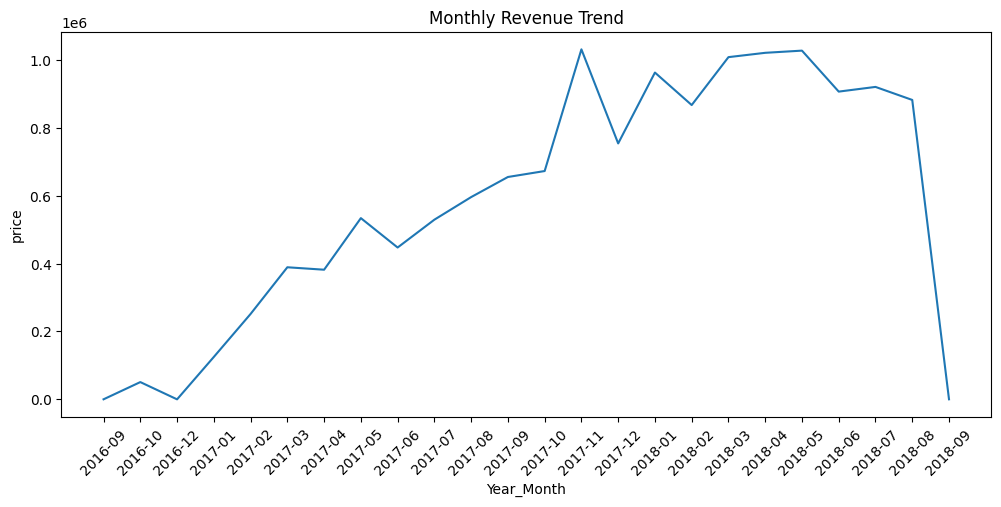

In [ ]:
monthly_revenue = (
    task1_df.groupby('Year_Month')['price'].sum().reset_index())

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_revenue,x='Year_Month',y='price')

plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.show()

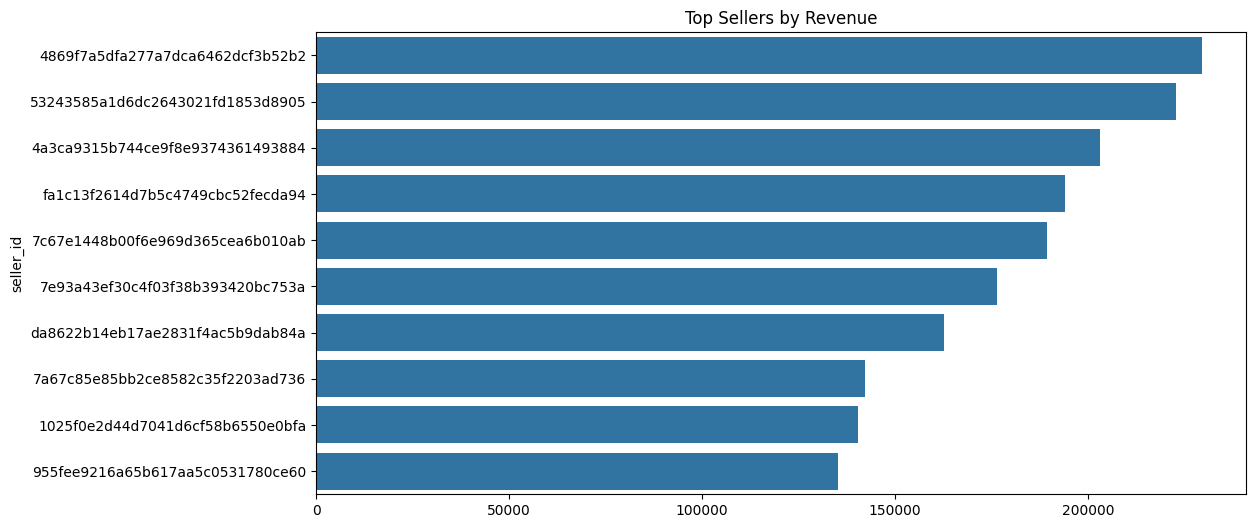

In [ ]:
top_sellers = (
    task3_df.groupby('seller_id')['price']
    .sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_sellers.values,
    y=top_sellers.index)

plt.title('Top Sellers by Revenue')
plt.show()

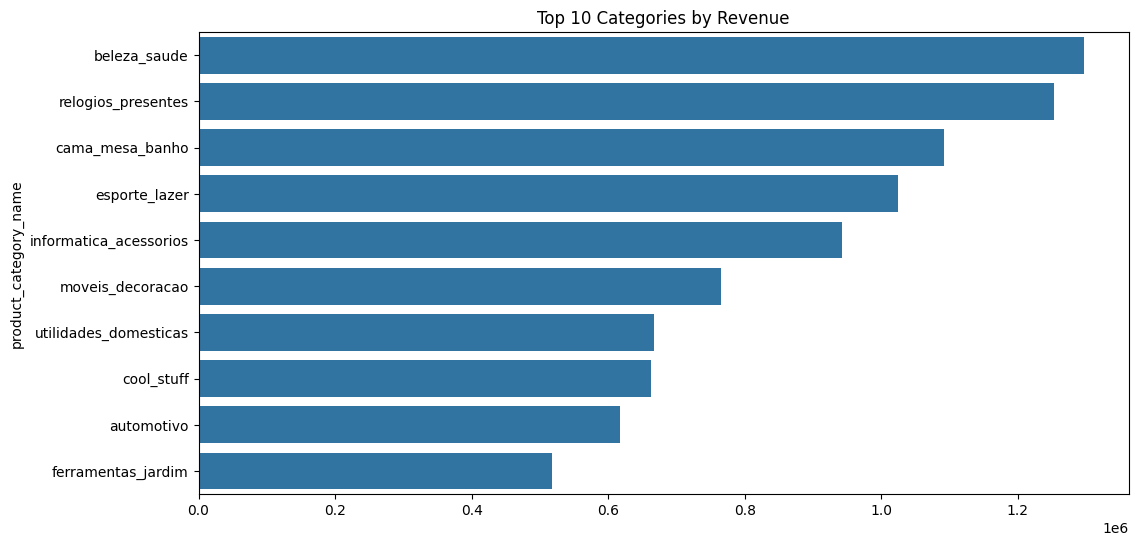

In [ ]:
top_categories = (
    task1_df.groupby('product_category_name')['price']
    .sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_categories.values,
    y=top_categories.index)

plt.title('Top 10 Categories by Revenue')
plt.show()

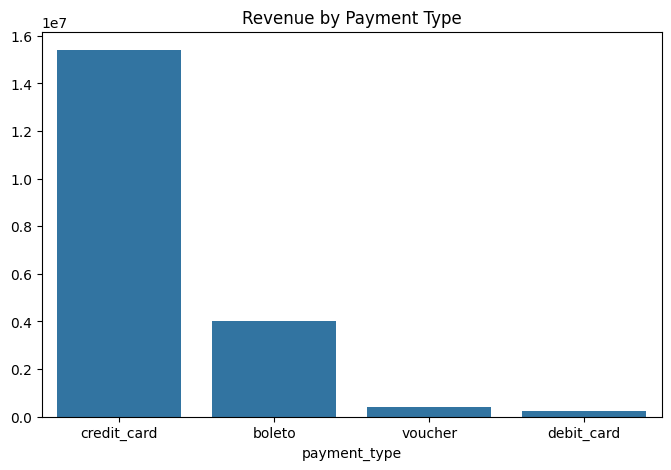

In [ ]:
payment_revenue = (
    task1_df.groupby('payment_type')['payment_value']
    .sum().sort_values(ascending=False))

plt.figure(figsize=(8,5))
sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values)

plt.title('Revenue by Payment Type')
plt.show()

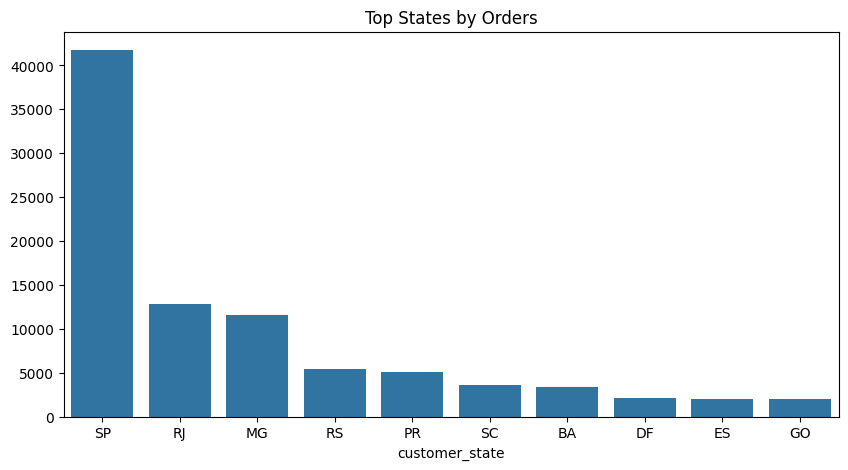

In [ ]:
orders_state = (
    task2_df.groupby('customer_state')['order_id']
    .nunique().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,5))
sns.barplot(
    x=orders_state.index,
    y=orders_state.values
)

plt.title('Top States by Orders')
plt.show()

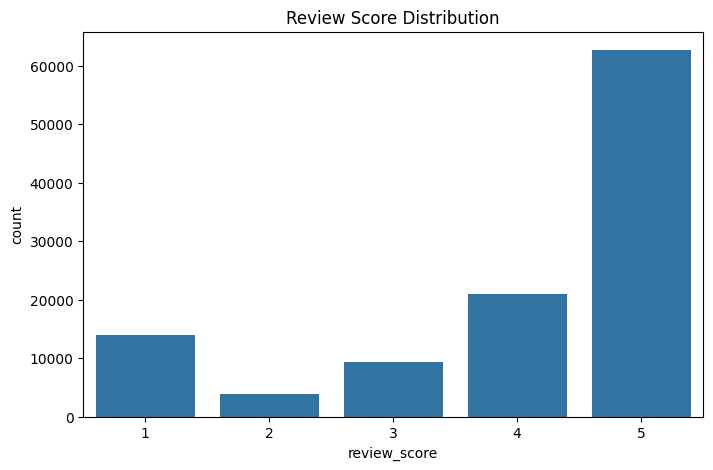

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=task4_df, x='review_score')

plt.title('Review Score Distribution')
plt.show()

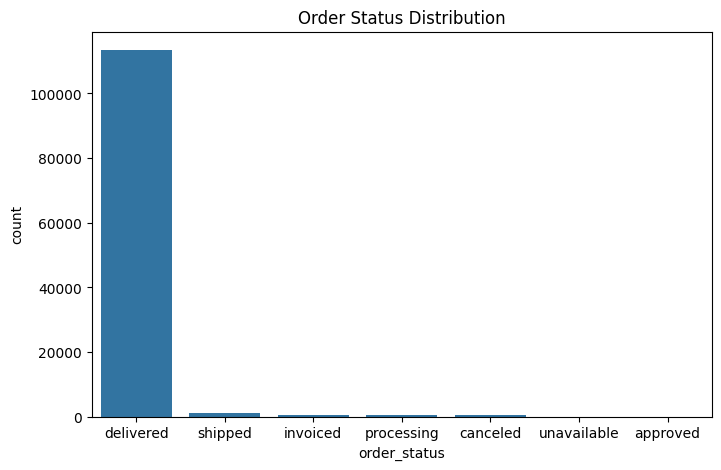

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=task1_df, x='order_status')

plt.title('Order Status Distribution')
plt.show()

In [ ]:
total_revenue = task1_df['price'].sum()
total_orders = task1_df['order_id'].nunique()
total_customers = task1_df['customer_id'].nunique()
avg_order_value = total_revenue / total_orders
late_delivery_rate = (task2_df['is_late'].sum() / len(task2_df) * 100)
avg_review_score = task4_df['review_score'].mean()
total_sellers = task3_df['seller_id'].nunique()
top_category = task1_df.groupby('product_category_name')['price'].sum().idxmax()
top_seller = task3_df.iloc[0]['seller_id']

print(f"Total Revenue :{total_revenue:,.2f}")
print(f"Average Order Value :{avg_order_value:,.2f}")

print(f"Total Orders :{total_orders:,}")
print(f"Total Customers :{total_customers:,}")

print(f"Late Delivery Rate :{late_delivery_rate:.2f}%")

print(f"Average Review Score :{avg_review_score:.2f}/5.00")

print(f"Total Sellers :{total_sellers:,}")

print(f"Top Category :{top_category}")
print(f"Top Seller :{top_seller}")


Total Revenue :14,016,224.75
Average Order Value :144.09
Total Orders :97,275
Total Customers :97,275
Late Delivery Rate :7.87%
Average Review Score :4.04/5.00
Total Sellers :3,095
Top Category :beleza_saude
Top Seller :3442f8959a84dea7ee197c632cb2df15


In [ ]:
task1_df.to_csv('sales_analysis.csv', index=False)
task2_df.to_csv('customer_analysis.csv', index=False)
task3_df.to_csv('seller_analysis.csv', index=False)
task4_df.to_csv('review_analysis.csv', index=False)